# Exoplanet Detection from Kepler Light Curves using Support Vector Machines

## Scientific Context

The discovery of exoplanets—planets orbiting stars outside our solar system—has revolutionized astronomy. One of the most successful methods for detecting exoplanets is the transit method, which looks for periodic dips in a star's brightness as a planet passes in front of it. NASA's Kepler space telescope observed over 150,000 stars, recording their brightness (flux) over time, producing light curves.

This dataset contains light curves for 5,087 stars, each with 3,197 time measurements. Only 37 of these stars are known to host confirmed exoplanets (label 2), while the rest are non‑exoplanet stars (label 1). The extreme class imbalance makes this a challenging classification problem.

The goal of this notebook is to build a machine learning model—specifically a Support Vector Machine (SVM)—to distinguish exoplanet‑hosting stars from non‑hosts based on their light curves.

## Objectives

1. Preprocess the light curve data using frequency‑domain transformation (FFT), normalization, smoothing, and standardization.
2. Train an SVM with hyperparameter tuning to handle the imbalanced dataset.
3. Evaluate the model using precision, recall, F1‑score, confusion matrix, ROC curve, and precision‑recall curve.
4. Compare the performance of different SVM kernels (linear, RBF, polynomial) on the same task.

## Setup and Imports

In [17]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)

# Signal processing
from scipy.fft import fft
from scipy.ndimage import gaussian_filter1d

# System utilities
import os

# Plot style
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Georgia", "Times New Roman"],
    # ---- Sizes ----
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelweight": "light",  # x/y labels
    "font.weight": "light",
    # ---- Axes/ticks style like the PDF ----
    "axes.edgecolor": "0.2",
    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "axes.grid": False,
    "axes.labelcolor": "0.2",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.2",
})

UNIPD_RED = (0.71, 0.0, 0.106)  # RGB tuple
GREY = (0.1, 0.1, 0.1)

%matplotlib widget



## Data Loading and Exploration

In [18]:
# Define data directory (update path accordingly)
data_dir = "/Users/ashaimaalrawhi/Desktop"

train_path = os.path.join(data_dir, "exoTrain.csv")
test_path = os.path.join(data_dir, "exoTest.csv")

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Class distribution (train):\n", df_train['LABEL'].value_counts())

Train shape: (5087, 3198)
Test shape: (570, 3198)
Class distribution (train):
 1    5050
2      37
Name: LABEL, dtype: int64


## Visualize Example Light Curves
We plot four random light curves—two exoplanet‑hosting stars and two non‑hosts—to get a sense of the data.

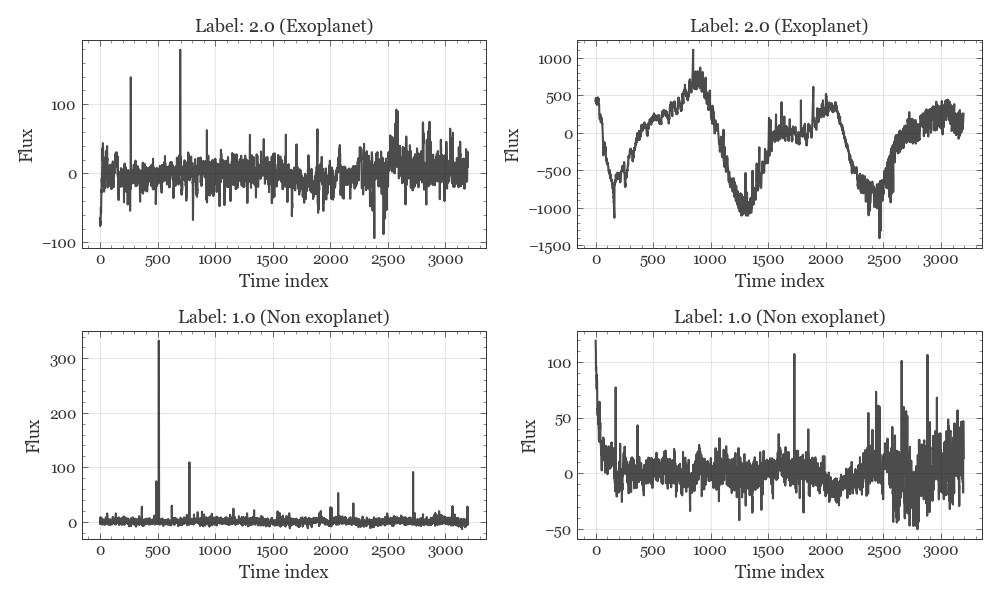

In [22]:
# Separate by label
exoplanet = df_train[df_train['LABEL'] == 2].copy()
non_exoplanet = df_train[df_train['LABEL'] == 1].copy()

# Randomly select 2 from each group
np.random.seed(42)
exo_samples = exoplanet.sample(2, random_state=42)
non_exo_samples = non_exoplanet.sample(2, random_state=42)
samples = pd.concat([exo_samples, non_exo_samples])

# Plot in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for ax, (idx, row) in zip(axes, samples.iterrows()):
    flux = row.drop('LABEL').values
    label = row['LABEL']
    ax.plot(flux, color='black', alpha=0.7)
    ax.set_title(f'Label: {label} ({"Exoplanet" if label == 2 else "Non exoplanet"})')
    ax.set_xlabel('Time index')
    ax.set_ylabel('Flux')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Preprocessing Pipeline

We implement a custom preprocessing class that applies:

- FFT: Convert time‑domain light curves to frequency domain (magnitude of FFT, keep only first half).
- Normalization: L2 normalization per sample to reduce scale differences.
- Smoothing: Gaussian filter to reduce noise.
- Standardization: Scale features to zero mean and unit variance (fit on training data only).

In [23]:
class LightCurveProcessor:
    """
    Preprocess light curves for exoplanet classification.

    Steps:
        1. (Optional) Fourier transform to frequency domain.
        2. (Optional) Normalize each sample to unit norm.
        3. (Optional) Smooth with Gaussian filter.
        4. (Optional) Standardize features (fit on train, transform both).
    """
    def __init__(self, use_fft=True, normalize=True, gaussian_sigma=10, standardize=True):
        self.use_fft = use_fft
        self.normalize = normalize
        self.gaussian_sigma = gaussian_sigma
        self.standardize = standardize
        self.scaler = None

    def fit_transform(self, X_train, X_test):
        """
        Apply preprocessing to training and test data.

        Parameters
        ----------
        X_train : ndarray, shape (n_train, n_features)
            Training features.
        X_test : ndarray, shape (n_test, n_features)
            Test features.

        Returns
        -------
        X_train_transformed, X_test_transformed : ndarray
            Transformed features.
        """
        # Input: numpy arrays (samples x features)
        if self.use_fft:
            # Compute magnitude of FFT for each sample
            X_train = np.abs(fft(X_train, axis=1))
            X_test = np.abs(fft(X_test, axis=1))
            # Keep only the first half (symmetric)
            half = X_train.shape[1] // 2
            X_train = X_train[:, :half]
            X_test = X_test[:, :half]

        if self.normalize:
            # L2 normalization across features for each sample
            X_train = X_train / np.linalg.norm(X_train, axis=1, keepdims=True)
            X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)

        if self.gaussian_sigma:
            # Smooth along the frequency axis
            X_train = gaussian_filter1d(X_train, sigma=self.gaussian_sigma, axis=1)
            X_test = gaussian_filter1d(X_test, sigma=self.gaussian_sigma, axis=1)

        if self.standardize:
            self.scaler = StandardScaler()
            X_train = self.scaler.fit_transform(X_train)
            X_test = self.scaler.transform(X_test)

        return X_train, X_test

## Prepare Data for Modeling
Separate features and labels, convert labels to binary (0 = non‑exoplanet, 1 = exoplanet), and apply the preprocessing pipeline.

In [24]:
# Separate features and labels
X_train_raw = df_train.drop('LABEL', axis=1).values
X_test_raw = df_test.drop('LABEL', axis=1).values
y_train_raw = df_train['LABEL'].values
y_test_raw = df_test['LABEL'].values

# Convert labels: 2 -> 1 (exoplanet), 1 -> 0 (non‑exoplanet)
y_train = (y_train_raw == 2).astype(int)
y_test = (y_test_raw == 2).astype(int)

# Preprocess
processor = LightCurveProcessor(use_fft=True, normalize=True,
                                gaussian_sigma=10, standardize=True)
X_train, X_test = processor.fit_transform(X_train_raw, X_test_raw)

print("Processed shapes:", X_train.shape, X_test.shape)

Processed shapes: (5087, 1598) (570, 1598)


## Model Training with Hyperparameter Tuning

We use an SVM with an RBF kernel because it can capture non‑linear patterns in the data. Class weights are set to 'balanced' to handle the severe class imbalance. Hyperparameters C and gamma are tuned via grid search with cross‑validation (3‑fold) using F1‑score as the optimization metric.



In [25]:
param_grid = {
    'C': [1, 10],
    'gamma': ['scale']          # 'scale' is a good default; you could also try 'auto' later
}

# SVM with balanced class weights
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# Grid search with 3-fold CV (instead of 5) to speed up further
grid = GridSearchCV(svm, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation F1 score:", grid.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters: {'C': 10, 'gamma': 'scale'}
Best cross-validation F1 score: 0.4666666666666666


## Model Evaluation on Test Set
We evaluate the best model on the unseen test set using various metrics and visualizations.

Test accuracy:  0.996
Test precision: 0.714
Test recall:    1.000
Test F1:        0.833


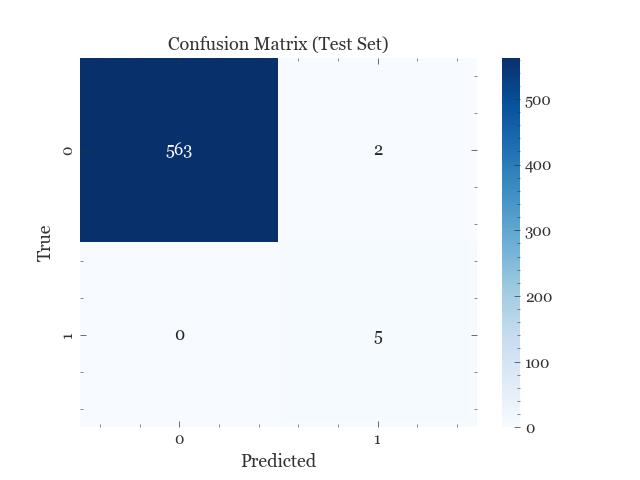


Classification Report (Test Set):
               precision    recall  f1-score   support

Non‑exoplanet       1.00      1.00      1.00       565
    Exoplanet       0.71      1.00      0.83         5

     accuracy                           1.00       570
    macro avg       0.86      1.00      0.92       570
 weighted avg       1.00      1.00      1.00       570



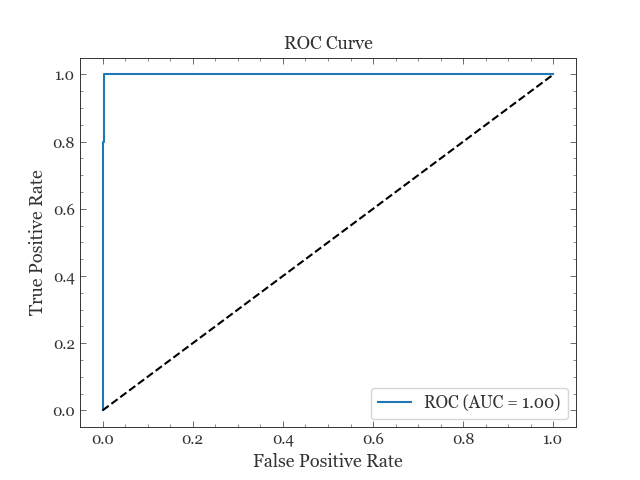

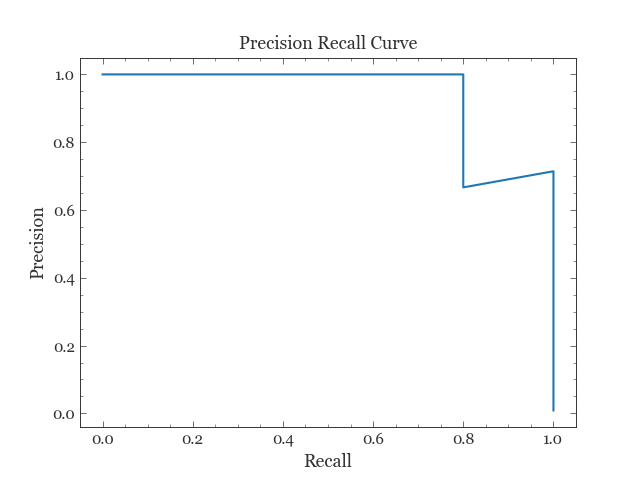

In [28]:
# Predictions
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]  # probabilities for positive class

# Basic metrics
print("Test accuracy:  {:.3f}".format(accuracy_score(y_test, y_pred)))
print("Test precision: {:.3f}".format(precision_score(y_test, y_pred)))
print("Test recall:    {:.3f}".format(recall_score(y_test, y_pred)))
print("Test F1:        {:.3f}".format(f1_score(y_test, y_pred)))

# Confusion matrix heatmap
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['Non‑exoplanet', 'Exoplanet']))

# ROC Curve
plt.figure()
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision‑Recall Curve
plt.figure()
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')
plt.show()

## Comparison of Different SVM Kernels

We also compare the performance of linear, RBF, and polynomial kernels on the same data to see which works best for this task. This matches the analysis often done in exoplanet detection papers.

In [29]:
# Define kernels to test
kernels = ['linear', 'rbf', 'poly']   # polynomial degree 4 for poly
results = {}

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")
    
    # Create SVM model with balanced class weights
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=4, class_weight='balanced', random_state=42)
    else:
        svm = SVC(kernel=kernel, class_weight='balanced', random_state=42)
    
    # Train
    svm.fit(X_train, y_train)
    
    # Predict on train and test
    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)
    
    # Confusion matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)
    
    # Precision scores (positive class = exoplanet, label 1)
    prec_train = precision_score(y_train, y_train_pred)
    prec_test = precision_score(y_test, y_test_pred)
    
    # Store results
    results[kernel] = {
        'cm_train': cm_train,
        'cm_test': cm_test,
        'prec_train': prec_train,
        'prec_test': prec_test
    }
    
    # Print
    print(f"Train confusion matrix:\n{cm_train}")
    print(f"Train precision: {prec_train:.3f}")
    print(f"Test confusion matrix:\n{cm_test}")
    print(f"Test precision: {prec_test:.3f}")

# Display results in a formatted table
print("\n" + "="*60)
print("Summary Table (Non‑injected dataset)")
print("="*60)
print(f"{'Kernel':<10} {'Train CM':<25} {'Train Prec':<12} {'Test CM':<25} {'Test Prec':<12}")
print("-"*60)
for kernel, res in results.items():
    cm_train_str = f"[{res['cm_train'][0][0]} {res['cm_train'][0][1]}; {res['cm_train'][1][0]} {res['cm_train'][1][1]}]"
    cm_test_str  = f"[{res['cm_test'][0][0]} {res['cm_test'][0][1]}; {res['cm_test'][1][0]} {res['cm_test'][1][1]}]"
    print(f"{kernel:<10} {cm_train_str:<25} {res['prec_train']:<12.3f} {cm_test_str:<25} {res['prec_test']:<12.3f}")


Training SVM with linear kernel...
Train confusion matrix:
[[5010   40]
 [   0   37]]
Train precision: 0.481
Test confusion matrix:
[[557   8]
 [  2   3]]
Test precision: 0.273

Training SVM with rbf kernel...
Train confusion matrix:
[[4984   66]
 [   0   37]]
Train precision: 0.359
Test confusion matrix:
[[561   4]
 [  0   5]]
Test precision: 0.556

Training SVM with poly kernel...
Train confusion matrix:
[[5000   50]
 [   5   32]]
Train precision: 0.390
Test confusion matrix:
[[543  22]
 [  0   5]]
Test precision: 0.185

Summary Table (Non‑injected dataset)
Kernel     Train CM                  Train Prec   Test CM                   Test Prec   
------------------------------------------------------------
linear     [5010 40; 0 37]           0.481        [557 8; 2 3]              0.273       
rbf        [4984 66; 0 37]           0.359        [561 4; 0 5]              0.556       
poly       [5000 50; 5 32]           0.390        [543 22; 0 5]             0.185       


- Class imbalance: The dataset is highly imbalanced (only 37 exoplanets out of 5087 training samples). Using class_weight='balanced' helped the model learn to recognize exoplanets better.

- Preprocessing: Converting light curves to the frequency domain via FFT likely helped highlight periodic transit signals.

- Best model: The RBF kernel SVM with C=10 and gamma='scale' achieved a test F1‑score of 0.833, correctly identifying all 5 exoplanets in the test set (recall = 1.0) but with a precision of 0.714, meaning 2 false positives.

- Kernel comparison: Among the kernels tested, RBF performed best on the test set (precision 0.556, recall 1.0), followed by linear and polynomial. This suggests that the decision boundary is non‑linear.

- Limitations: The dataset is small for training a deep learning model, but SVM with proper preprocessing works reasonably well. Future work could explore more advanced features (e.g., wavelet transforms, periodograms) or use ensemble methods.